# A-based clustering -> WU-based clustering of the remainder


1. Cluster all genes by PCoA + inside/outside density ratio (A) and visualize the
   separation
2. Fix high-`mean_A` clusters as "internal", then re-cluster the remaining genes by
   PCoA + uniformity
3. Combine internal + remaining

## 1. Setup

In [2]:
import scomv
import stlearn as st
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import cv2
from adjustText import adjust_text

adata = st.ReadXenium(
    feature_cell_matrix_file="../tutorial_data/xenium_data/cell_feature_matrix.h5",
    cell_summary_file="../tutorial_data/xenium_data/cells.csv.gz",
    library_id="example data",
    image_path=None,
    scale=1,
    spot_diameter_fullres=10,
)

sc.pp.filter_genes(adata, min_cells=300)

N_COL = int((adata.obs.imagecol.max() - adata.obs.imagecol.min()) / 10)
N_ROW = int((adata.obs.imagerow.max() - adata.obs.imagerow.min()) / 10)
grid = st.tl.cci.grid(adata, n_row=N_ROW, n_col=N_COL, n_cpus=10, verbose=False)

from scomv.preparation.skny_calc_distance import calculate_distance

grid = calculate_distance(grid, pos_marker_ls=["CDH1", "EPCAM"])

sc.pp.filter_cells(adata, min_genes=10)
print(adata)

/Users/nomura/miniconda3/envs/scomv-pip-2/lib/python3.11/site-packages/stlearn/tl/cci/het.py:206: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit(parallel=True, nopython=False)


[calculate_distance] N_ROW=547, N_COL=752, positive cells in grid=100012/411344
AnnData object with n_obs × n_vars = 163565 × 312
    obs: 'imagecol', 'imagerow', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


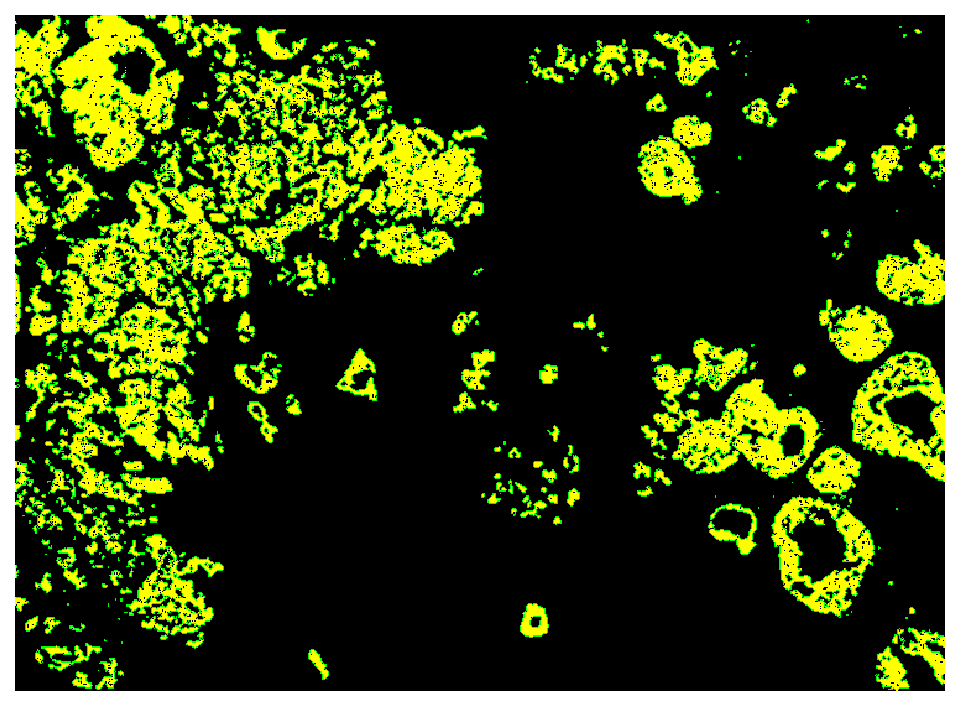

In [3]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.imshow(cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB),
          interpolation="nearest")
ax.axis("off")
plt.show()

In [4]:
import plotly.express as px
import plotly.io as pio
import cv2
import numpy as np

# Convert BGR (OpenCV) image to RGB for Plotly display
img = cv2.cvtColor(grid.uns["marker_median_delineation"], cv2.COLOR_BGR2RGB)

scale = 10  # spatial scaling factor

fig = px.imshow(img)

h, w = img.shape[:2]

# ---- Scale axis tick labels by a factor of 10 ----
step = 200
fig.update_xaxes(
    tickmode="array",
    tickvals=list(range(0, w, step)),
    ticktext=[str(v * scale) for v in range(0, w, step)]
)
fig.update_yaxes(
    tickmode="array",
    tickvals=list(range(0, h, step)),
    ticktext=[str(v * scale) for v in range(0, h, step)]
)

# ---- Create a full-resolution coordinate grid for hover display ----
# xx: scaled x-coordinates for each pixel (shape: h × w)
# yy: scaled y-coordinates for each pixel (shape: h × w)
xx = (np.arange(w)[None, :] * scale).repeat(h, axis=0)
yy = (np.arange(h)[:, None] * scale).repeat(w, axis=1)

# Stack into (h, w, 2) so hover can access scaled x and y
custom = np.dstack([xx, yy])

# ---- Override hover text to show scaled spatial coordinates ----
fig.update_traces(
    customdata=custom,
    hovertemplate="x: %{customdata[0]}<br>y: %{customdata[1]}<extra></extra>"
)

fig.update_layout(
    xaxis_title="x",
    yaxis_title="y",
    height=800
)

# Use the notebook-connected renderer for interactive display
pio.renderers.default = "notebook_connected"

fig.show()

# ↓↓ Zooming and cropping are supported interactively ↓↓

In [5]:
# Attach region / region_10 to grid.obs (referenced by extract_roi)
df_shotest = getattr(grid, "shortest")
df_grid = grid.to_df()

df_grid = pd.merge(
    pd.DataFrame(index=["grid_" + str(i + 1) for i in range(N_ROW * N_COL)]),
    df_grid, right_index=True, left_index=True, how="left",
).fillna(np.nan)

df_region = pd.DataFrame(
    np.array(df_shotest["region"]).reshape(N_ROW, N_COL).T.reshape(N_ROW * N_COL),
    index=["grid_" + str(i + 1) for i in range(N_ROW * N_COL)], columns=["region"],
)

df_grid_region = pd.merge(df_grid, df_region, right_index=True, left_index=True, how="left")
df_grid_region = df_grid_region.dropna()

grid.obs = pd.merge(grid.obs, df_grid_region[["region"]], right_index=True, left_index=True, how="left")

grid.obs["region_10"] = [str(i * 10) for i in grid.obs["region"]]
grid.obs["region_10"] = [
    "(" + str(int(float(i.split(", ")[0][1:]))) + ", " + str(int(float(i.split(", ")[-1][:-1]))) + "]"
    if i != "nan" else np.nan
    for i in grid.obs["region_10"]
]
grid.obs["region_10"] = grid.obs["region_10"].replace({"(-150, -120]": np.nan})

In [6]:
from scomv.gene_pipeline import SCOMVPipeline

gene_pipe = SCOMVPipeline(adata=adata, grid=grid, bin_size=10)
gene_out = gene_pipe.run(roi=(2400, 3400, 2400, 3800))

coords = gene_pipe.coords[["PC1", "PC2"]]
print(f"n selected genes: {len(gene_pipe.selected_genes)}")
coords.head()

n selected genes: 312


,PC1,PC2
ABCC11,-0.088127,0.050468
ACTA2,0.144600,-0.157408
ACTG2,0.047600,-0.196735
ADAM9,0.059718,-0.224247
ADGRE5,-0.248515,-0.074211


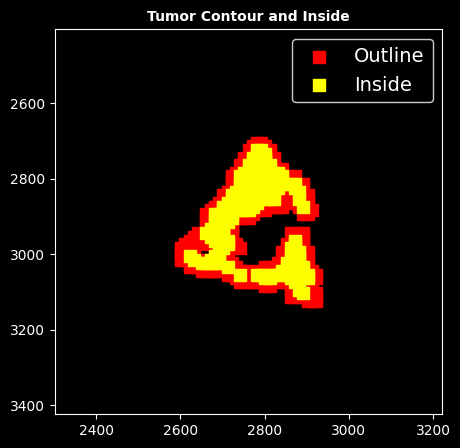

In [7]:
from scomv.preparation.choose_roi import contour_regions

# gene_pipe.run() already computed this internally (show=False); re-run with
# show=True just to display the contour/inside-region plot.
g_x_cont, g_y_cont, g_x_inside, g_y_inside = contour_regions(
    gene_pipe.filtered_shortest, adata,
    min_x=gene_pipe.contour_bounds[0], max_x=gene_pipe.contour_bounds[1],
    min_y=gene_pipe.contour_bounds[2], max_y=gene_pipe.contour_bounds[3],
    show=True,
)

## 2. Compute uniformity / inside-outside density ratio (A)

In [8]:
import math
from scomv.gene_module import compute_gene_uniformity
from scomv.tumor_solid import weighted_mean_across_bins
import importlib
import scomv.gene_module
from scomv.gene_module import cluster_genes_by_pcoa

# Distance bins: 10-100µm. Weight sqrt(15/d) (closer bins weighted more), n_ref=24.
ALL_DIST_BINS_G = {
    "10-20µm": (16, 15), "20-30µm": (17, 25), "30-40µm": (18, 35),
    "40-50µm": (19, 45), "50-60µm": (20, 55), "60-70µm": (21, 65),
    "70-80µm": (22, 75), "80-90µm": (23, 85), "90-100µm": (24, 95),
}
DIST_BINS_G = {k: idx for k, (idx, _) in ALL_DIST_BINS_G.items()}
BIN_WEIGHTS_G = {k: math.sqrt(15 / d) for k, (_, d) in ALL_DIST_BINS_G.items()}

wu_df = compute_gene_uniformity(
    gene_pipe.subset_grid, gene_pipe.selected_genes, gene_pipe.polar_counts_list,
    DIST_BINS_G, n_ref=24,
)
wu_score = weighted_mean_across_bins(wu_df, BIN_WEIGHTS_G)

In [9]:
from scomv.gene_module import compute_inside_outside_density_ratio

density_ratio = compute_inside_outside_density_ratio(
    gene_pipe.selected_genes, gene_pipe.polar_counts_list, gene_pipe.radius_bins,
    n_inside=len(gene_pipe.inside_points), n_total=len(gene_pipe.xy_list),
)
density_ratio.describe()

count    312.000000
mean       1.751496
std        2.274712
min        0.000000
25%        0.138436
50%        0.607117
75%        2.730376
max       12.331711
Name: density_ratio, dtype: float64

## 3. Stage 1 — cluster all genes by PCoA + A

`min_cluster_size=12`, `A_WEIGHT=0.3`, `method="leaf"`, `epsilon=0.0`.

In [10]:
from scomv.gene_module import cluster_genes_by_pcoa

MIN_CLUSTER_SIZE = 12
A_WEIGHT = 0.3

labels_a, cluster_info_a = cluster_genes_by_pcoa(
    coords,
    extra_axes={"mean_A": (density_ratio, A_WEIGHT)},
    min_cluster_size=MIN_CLUSTER_SIZE,
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.0,
)

print(f"n clusters: {len(cluster_info_a)}  (min_cluster_size={MIN_CLUSTER_SIZE})")
print(f"{'cluster':<8}{'n':>5}{'mean_A':>10}")
for cid, info in cluster_info_a.items():
    print(f"C{cid:<7}{info['n']:>5}{info['mean_A']:>10.3f}")

n clusters: 12  (min_cluster_size=12)
cluster     n    mean_A
C0         12     0.101
C1         15     0.102
C2         20     0.202
C3         42     0.213
C4         15     0.239
C5         29     0.525
C6         31     0.818
C7         27     0.619
C8         30     2.000
C9         24     1.871
C10        39     4.528
C11        28     6.727


## 4. Fix internal genes (mean_A ≥ A_THRESH)

`A_THRESH` is a real threshold on the density ratio itself (how much denser the
inside is than the outside) — it is not something to tune by eyeballing how the genes
split.

In [11]:
A_THRESH = 1.2

internal_summary = {cid: info for cid, info in cluster_info_a.items() if info["mean_A"] >= A_THRESH}
internal_genes = set(g for info in internal_summary.values() for g in info["genes"])
remaining_genes = [g for g in coords.index if g not in internal_genes and g in wu_score.index]

print(f"internal clusters: {len(internal_summary)}  (genes: {len(internal_genes)})")
print(f"remaining genes: {len(remaining_genes)}")

internal clusters: 4  (genes: 121)
remaining genes: 191


### Stage 1 visualization (color only the internal clusters, gray background for the rest)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


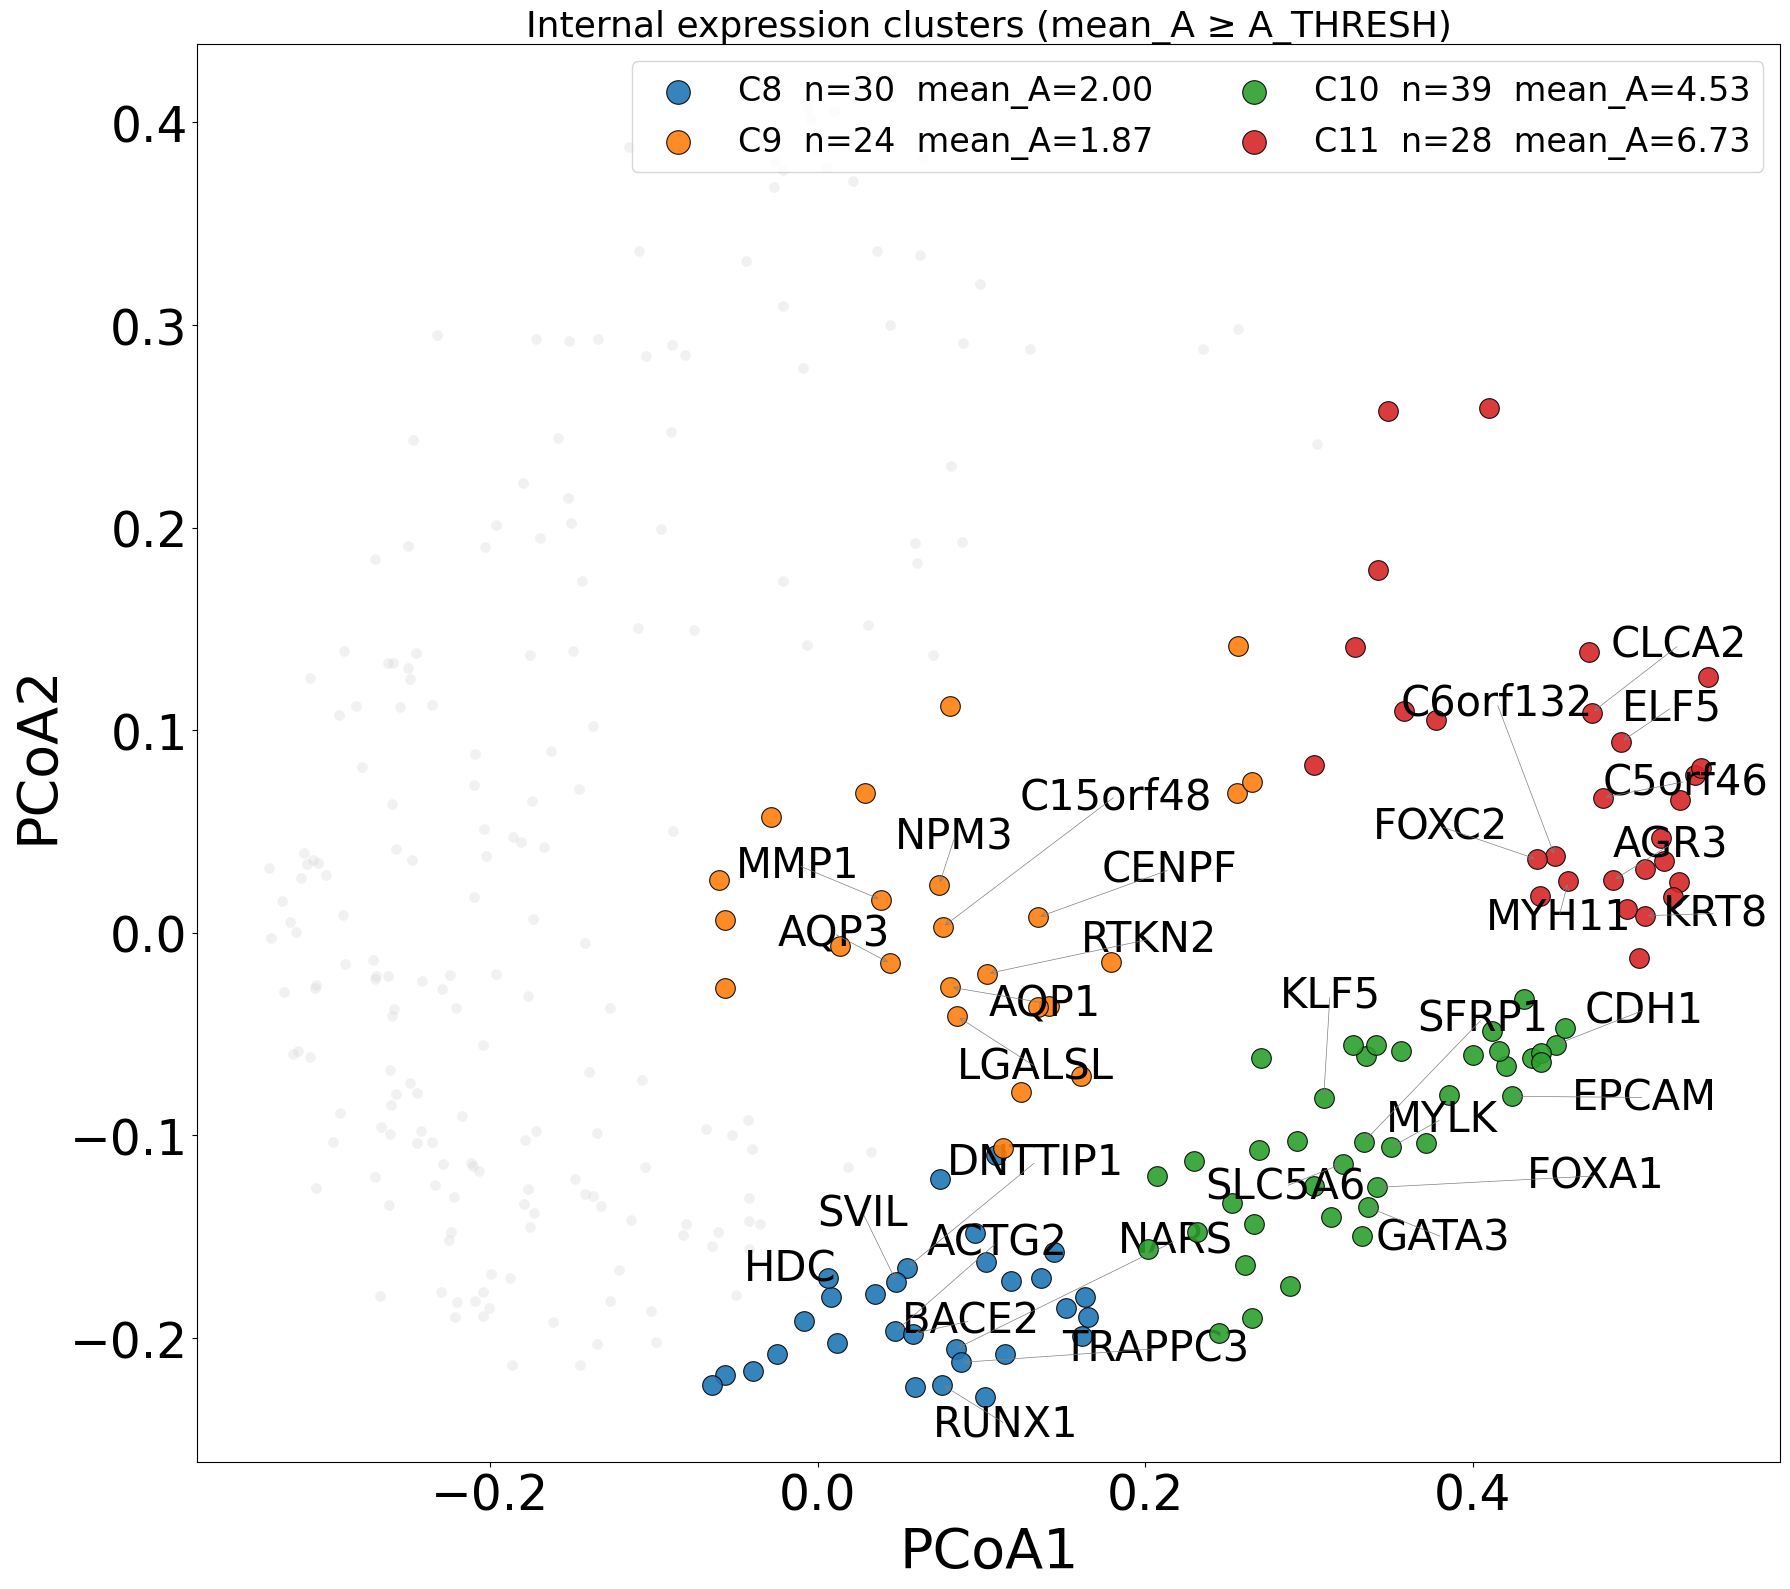

In [12]:
from scomv.gene_module import select_cluster_annotation_genes

t_cells     = {"CD3D", "CD3E", "CD4", "CD247", "CD8A", "GZMA", "TRAC"}
b_cells     = {"CD19", "BANK1", "MS4A1", "TCL1A", "CD79A"}
macrophage  = {"CD68", "CD80", "CD86", "CD163"}
epithelial  = {"CDH1", "EPCAM", "KRT8"}
endothelial = {"CD93", "PECAM1", "VWF"}
fibroblast  = {"POSTN", "LUM", "MMP2"}
marker_genes = t_cells | b_cells | macrophage | epithelial | endothelial | fibroblast

def plot_highlighted_clusters(highlight_summary, background_genes, title, value_key, value_label):
    """Color only the highlight_summary clusters; background_genes are drawn as gray
    background points. Each cluster gets at least 8 annotations, preferring
    marker_genes and filling in with genes near the cluster centroid."""
    cluster_annot = select_cluster_annotation_genes(
        highlight_summary, coords, preset_genes=marker_genes, min_annotations=8,
    )
    cmap = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(18, 16), dpi=100)

    bg_x = [coords.loc[g, "PC1"] for g in background_genes]
    bg_y = [coords.loc[g, "PC2"] for g in background_genes]
    ax.scatter(bg_x, bg_y, color="lightgray", s=60, alpha=0.3, linewidths=0, zorder=1)

    texts = []
    for i, (cid, info) in enumerate(highlight_summary.items()):
        color = cmap[i % len(cmap)]
        genes_c = info["genes"]
        xs = [coords.loc[g, "PC1"] for g in genes_c]
        ys = [coords.loc[g, "PC2"] for g in genes_c]
        ax.scatter(xs, ys, color=color, s=200, alpha=0.9, edgecolors="black", linewidths=0.8, zorder=3,
                   label=f"C{cid}  n={info['n']}  {value_label}={info[value_key]:.2f}")
        for g in genes_c:
            if g in cluster_annot[cid]:
                texts.append(ax.text(coords.loc[g, "PC1"], coords.loc[g, "PC2"], g, fontsize=30, color="black"))

    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
        only_move={"points": "xy", "text": "xy"},
        force_text=1.5, force_points=1.0,
        expand_text=(1.2, 1.2), expand_points=(1.2, 1.2),
        lim=200, precision=0.01, autoalign="y",
    )
    ax.set_xlabel("PCoA1", fontsize=40); ax.set_ylabel("PCoA2", fontsize=40)
    ax.tick_params(labelsize=35)
    ax.set_title(title, fontsize=26)
    ax.legend(fontsize=24, markerscale=1.2, ncol=2, loc="best")
    plt.tight_layout()
    plt.show()

background_genes_stage1 = [g for g in coords.index if g not in internal_genes]
plot_highlighted_clusters(
    internal_summary, background_genes_stage1,
    "Internal expression clusters (mean_A ≥ A_THRESH)",
    value_key="mean_A", value_label="mean_A",
)

In [13]:
print("POSTN A value:", density_ratio["POSTN"])
print("C8 genes:", cluster_info_a[8]["genes"])  # or whichever cluster number applies

POSTN A value: 0.0995365722010692
C8 genes: ['ACTA2', 'ACTG2', 'ADAM9', 'APOC1', 'BACE2', 'CCDC6', 'CTTN', 'CXCL16', 'DNTTIP1', 'EGFR', 'ENAH', 'FBLIM1', 'FSTL3', 'HDC', 'LARS', 'MDM2', 'NARS', 'POLR2J3', 'QARS', 'RUNX1', 'SDC4', 'SH3YL1', 'SMS', 'SRPK1', 'SVIL', 'TMEM147', 'TOMM7', 'TRAPPC3', 'USP53', 'ZNF562']


In [14]:
import numpy as np
import hdbscan
from sklearn.preprocessing import StandardScaler

genes_check = list(coords.index)
pc1 = np.array([coords.loc[g, "PC1"] for g in genes_check])
pc2 = np.array([coords.loc[g, "PC2"] for g in genes_check])
a_g = np.array([density_ratio[g] for g in genes_check])

# Buggy version (weight applied before standardizing — same formula as the original notebook)
feat_buggy = np.column_stack([pc1, pc2, a_g * A_WEIGHT])
feat_buggy_sc = StandardScaler().fit_transform(feat_buggy)
clusterer_buggy = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=1,
                                   cluster_selection_method="eom", prediction_data=True)
labels_buggy = clusterer_buggy.fit_predict(feat_buggy_sc).copy()
if (labels_buggy == -1).any():
    soft = hdbscan.all_points_membership_vectors(clusterer_buggy)
    idx = np.where(labels_buggy == -1)[0]
    labels_buggy[idx] = soft[idx].argmax(axis=1)

postn_i = genes_check.index("POSTN")
postn_cluster_buggy = labels_buggy[postn_i]
mean_a_buggy = a_g[labels_buggy == postn_cluster_buggy].mean()
print(f"[buggy] POSTN's cluster mean_A = {mean_a_buggy:.3f}  internal? {mean_a_buggy >= A_THRESH}")

# Fixed version (exactly what cluster_genes_by_pcoa does internally)
postn_cluster_fixed = [cid for cid, info in cluster_info_a.items() if "POSTN" in info["genes"]][0]
mean_a_fixed = cluster_info_a[postn_cluster_fixed]["mean_A"]
print(f"[fixed] POSTN's cluster mean_A = {mean_a_fixed:.3f}  internal? {mean_a_fixed >= A_THRESH}")

[buggy] POSTN's cluster mean_A = 0.243  internal? False
[fixed] POSTN's cluster mean_A = 0.818  internal? False


## 5. Stage 2 — re-cluster the remainder by WU

`min_cluster_size=10`, `B_WEIGHT=0.5`, `method="leaf"`, `epsilon=0.1`.

In [15]:
MIN_CLUSTER_SIZE_R = 10
B_WEIGHT = 0.5

labels_wu, remaining_summary = cluster_genes_by_pcoa(
    coords,
    extra_axes={"mean_wu": (wu_score, B_WEIGHT)},
    genes=remaining_genes,
    min_cluster_size=MIN_CLUSTER_SIZE_R,
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.1,
)

print(f"n clusters: {len(remaining_summary)}  (min_cluster_size={MIN_CLUSTER_SIZE_R})")
print(f"{'cluster':<8}{'n':>5}{'mean_wu':>10}")
for cid, info in remaining_summary.items():
    print(f"C{cid:<7}{info['n']:>5}{info['mean_wu']:>10.3f}")

n clusters: 7  (min_cluster_size=10)
cluster     n   mean_wu
C0         19     0.450
C1         38     0.371
C2         27     0.112
C3         16     0.074
C4         49     0.562
C5         12     0.013
C6         30     0.019


### Stage 2 visualization (color only the remaining clusters, gray background for internal)

Combined clusters: 11
  C1 [internal]  n=30  mean_A=2.00
  C2 [internal]  n=24  mean_A=1.87
  C3 [internal]  n=39  mean_A=4.53
  C4 [internal]  n=28  mean_A=6.73
  C5 [remaining]  n=19  mean_wu=0.450
  C6 [remaining]  n=38  mean_wu=0.371
  C7 [remaining]  n=27  mean_wu=0.112
  C8 [remaining]  n=16  mean_wu=0.074
  C9 [remaining]  n=49  mean_wu=0.562
  C10 [remaining]  n=12  mean_wu=0.013
  C11 [remaining]  n=30  mean_wu=0.019


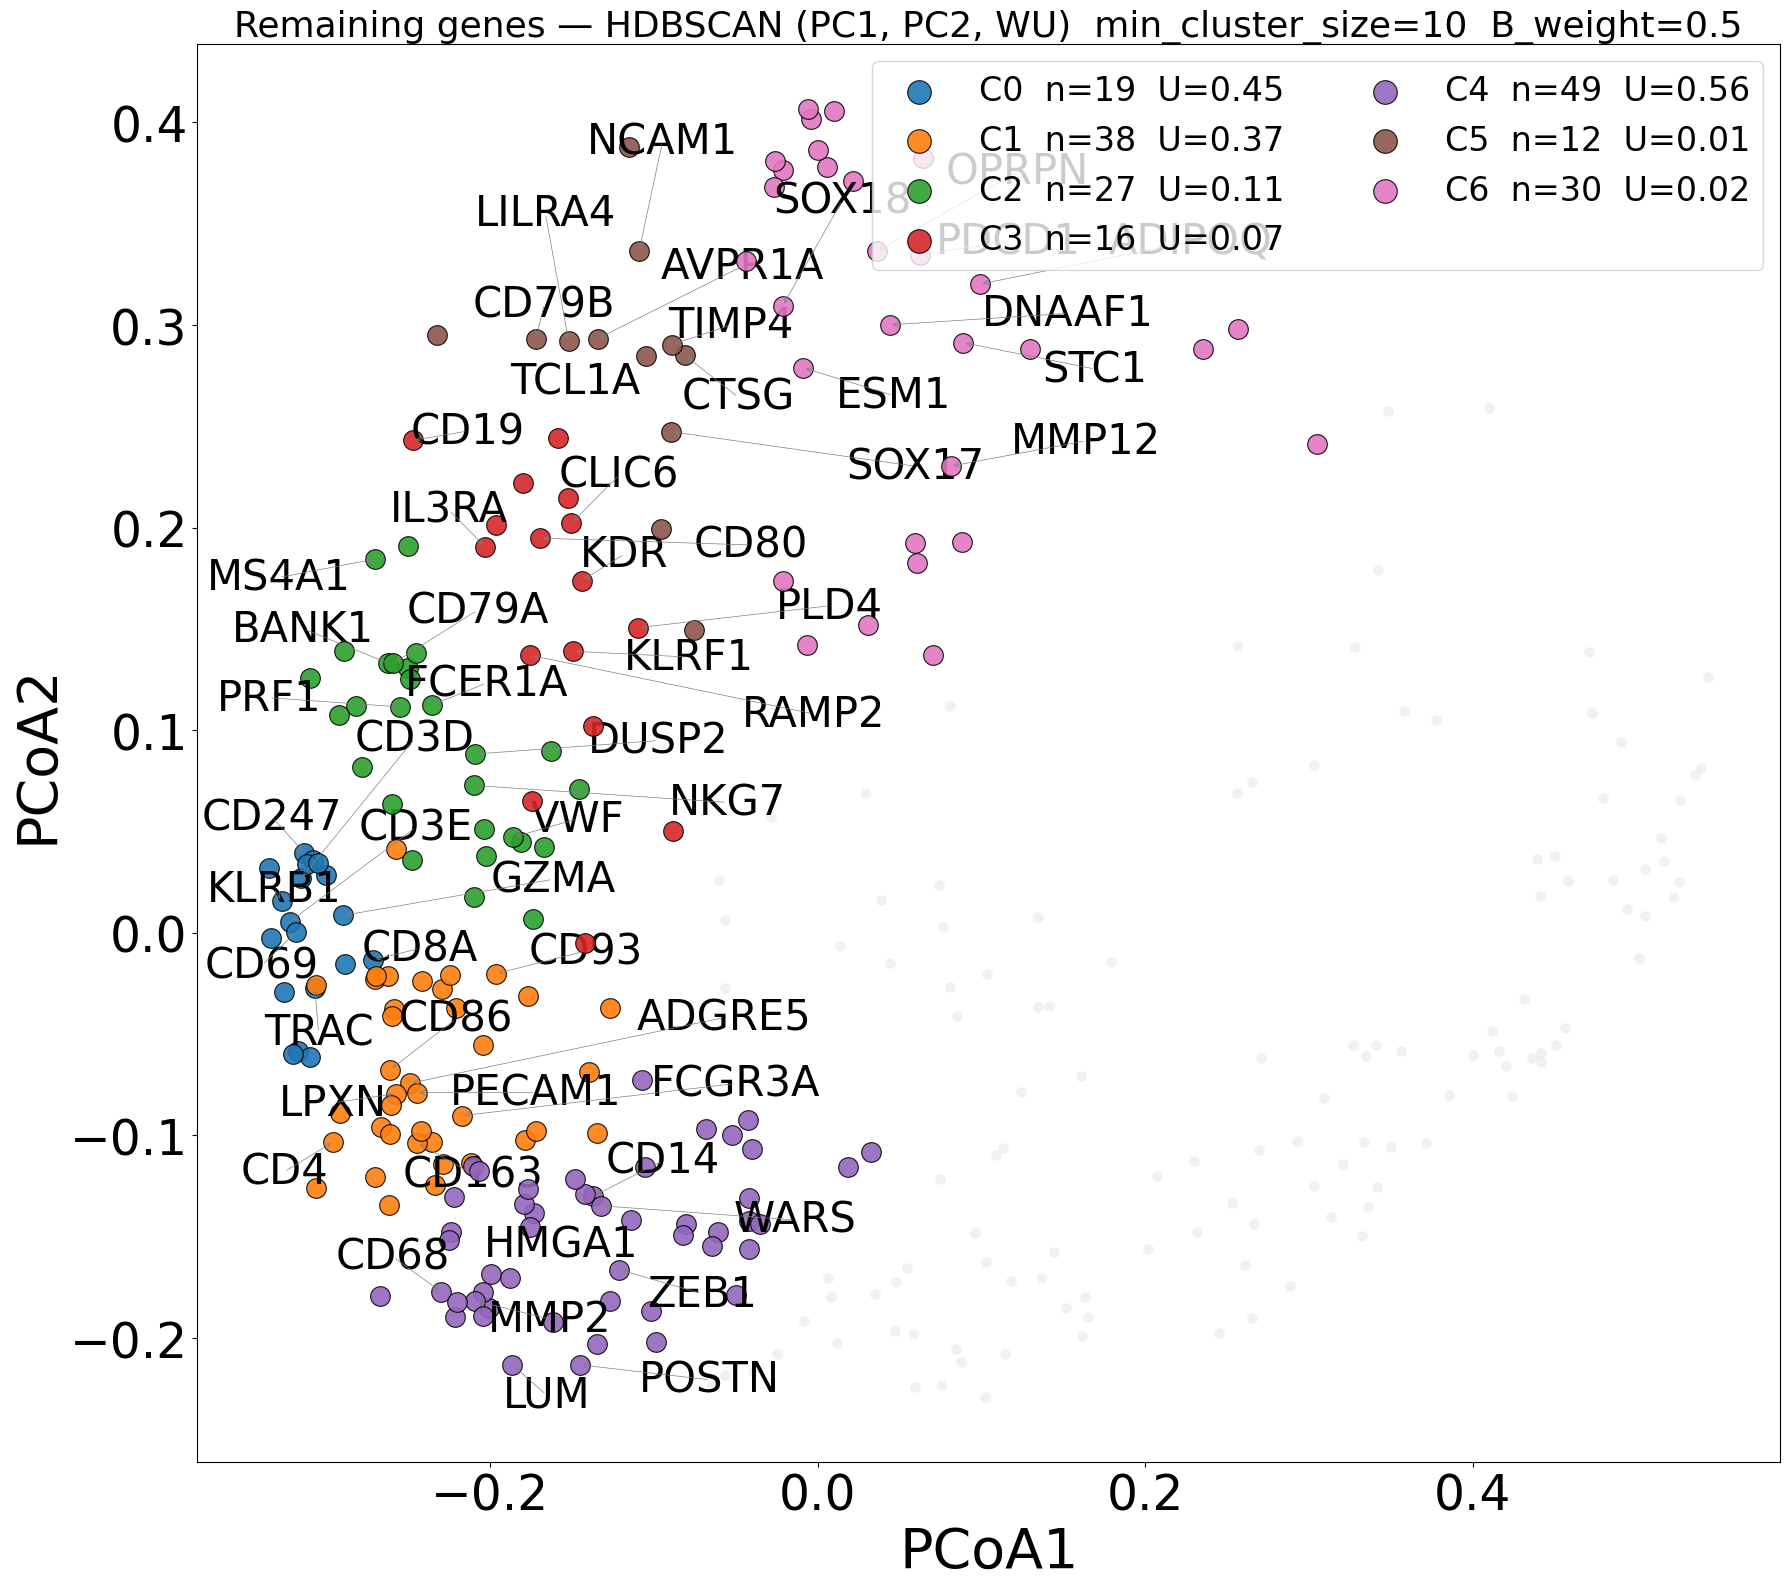

In [16]:
from scomv.gene_module import combine_cluster_summaries

unified = combine_cluster_summaries(("internal", internal_summary), ("remaining", remaining_summary))
print(f"Combined clusters: {len(unified)}")
for num, info in unified.items():
    score = f"mean_A={info['mean_A']:.2f}" if info["source"] == "internal" else f"mean_wu={info['mean_wu']:.3f}"
    print(f"  C{num} [{info['source']}]  n={info['n']}  {score}")

plot_highlighted_clusters(
    remaining_summary, list(internal_genes),
    f"Remaining genes — HDBSCAN (PC1, PC2, WU)  min_cluster_size={MIN_CLUSTER_SIZE_R}  B_weight={B_WEIGHT}",
    value_key="mean_wu", value_label="U",
)

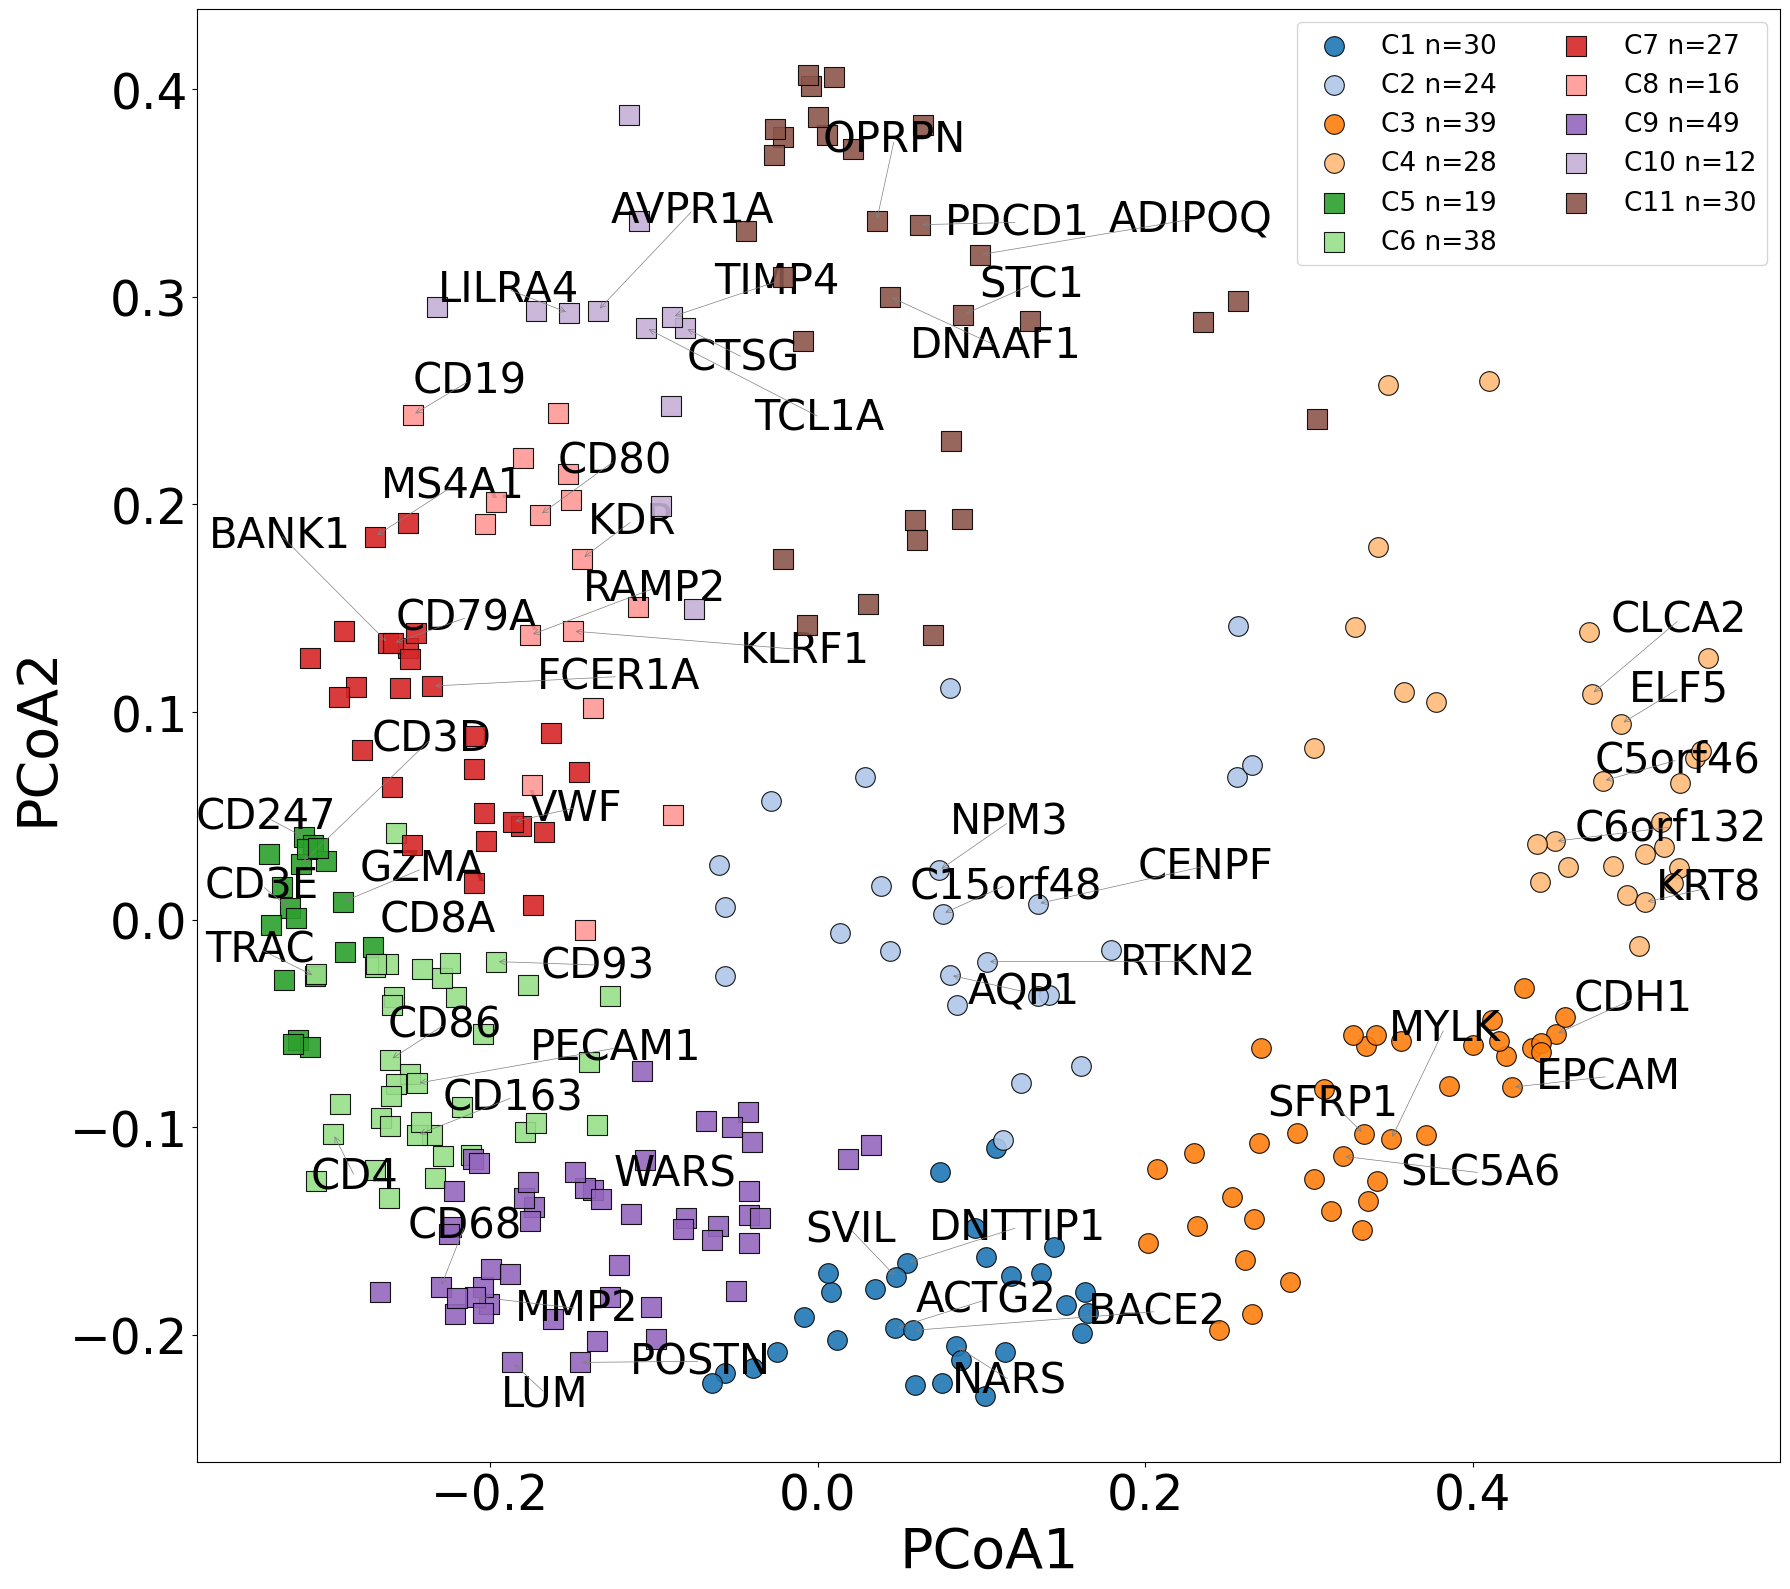

In [17]:
# Combined clustering result (internal + remaining, all colored together)
cluster_annot_all = select_cluster_annotation_genes(unified, coords, preset_genes=marker_genes, min_annotations=5)

cmap_combined = plt.cm.tab20.colors
fig, ax = plt.subplots(figsize=(18, 16), dpi=100)

texts = []
for i, (num, info) in enumerate(unified.items()):
    color = cmap_combined[i % len(cmap_combined)]
    genes_c = info["genes"]
    xs = [coords.loc[g, "PC1"] for g in genes_c]
    ys = [coords.loc[g, "PC2"] for g in genes_c]
    mkr = "o" if info["source"] == "internal" else "s"
    ax.scatter(xs, ys, color=color, s=200, alpha=0.9, edgecolors="black", linewidths=0.8, zorder=3,
               marker=mkr, label=f"C{num} n={info['n']}")
    for g in genes_c:
        if g in cluster_annot_all[num]:
            texts.append(ax.text(coords.loc[g, "PC1"], coords.loc[g, "PC2"], g, fontsize=30, color="black"))

classified = set(g for info in unified.values() for g in info["genes"])
unclassified = [g for g in coords.index if g not in classified]
ux = [coords.loc[g, "PC1"] for g in unclassified]
uy = [coords.loc[g, "PC2"] for g in unclassified]
ax.scatter(ux, uy, color="lightgray", s=60, alpha=0.3, linewidths=0, zorder=1)

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
    only_move={"points": "xy", "text": "xy"},
    force_text=1.5, force_points=1.0,
    expand_text=(1.2, 1.2), expand_points=(1.2, 1.2),
    lim=200, precision=0.01, autoalign="y",
)
ax.set_xlabel("PCoA1", fontsize=40); ax.set_ylabel("PCoA2", fontsize=40)
ax.tick_params(labelsize=35)
#ax.set_title("Combined clustering result", fontsize=26)
ax.legend(fontsize=19, markerscale=1.0, ncol=2, loc="best")
plt.tight_layout()
plt.show()

In [18]:
# All clusters × 20µm-bin presence fraction
from scomv.gene_module import compute_presence_fraction_map, plot_presence_fraction_grid

pres_maps = {}
pres_colors = {}
for i, (num, info) in enumerate(unified.items()):
    score = f"A={info['mean_A']:.2f}" if info["source"] == "internal" else f"WU={info['mean_wu']:.3f}"
    label = f"C{num}  n={info['n']}\n{score}"
    pres_maps[label] = compute_presence_fraction_map(gene_pipe.subset_grid, info["genes"], bin_size_um=20)
    pres_colors[label] = cmap_combined[i % len(cmap_combined)]

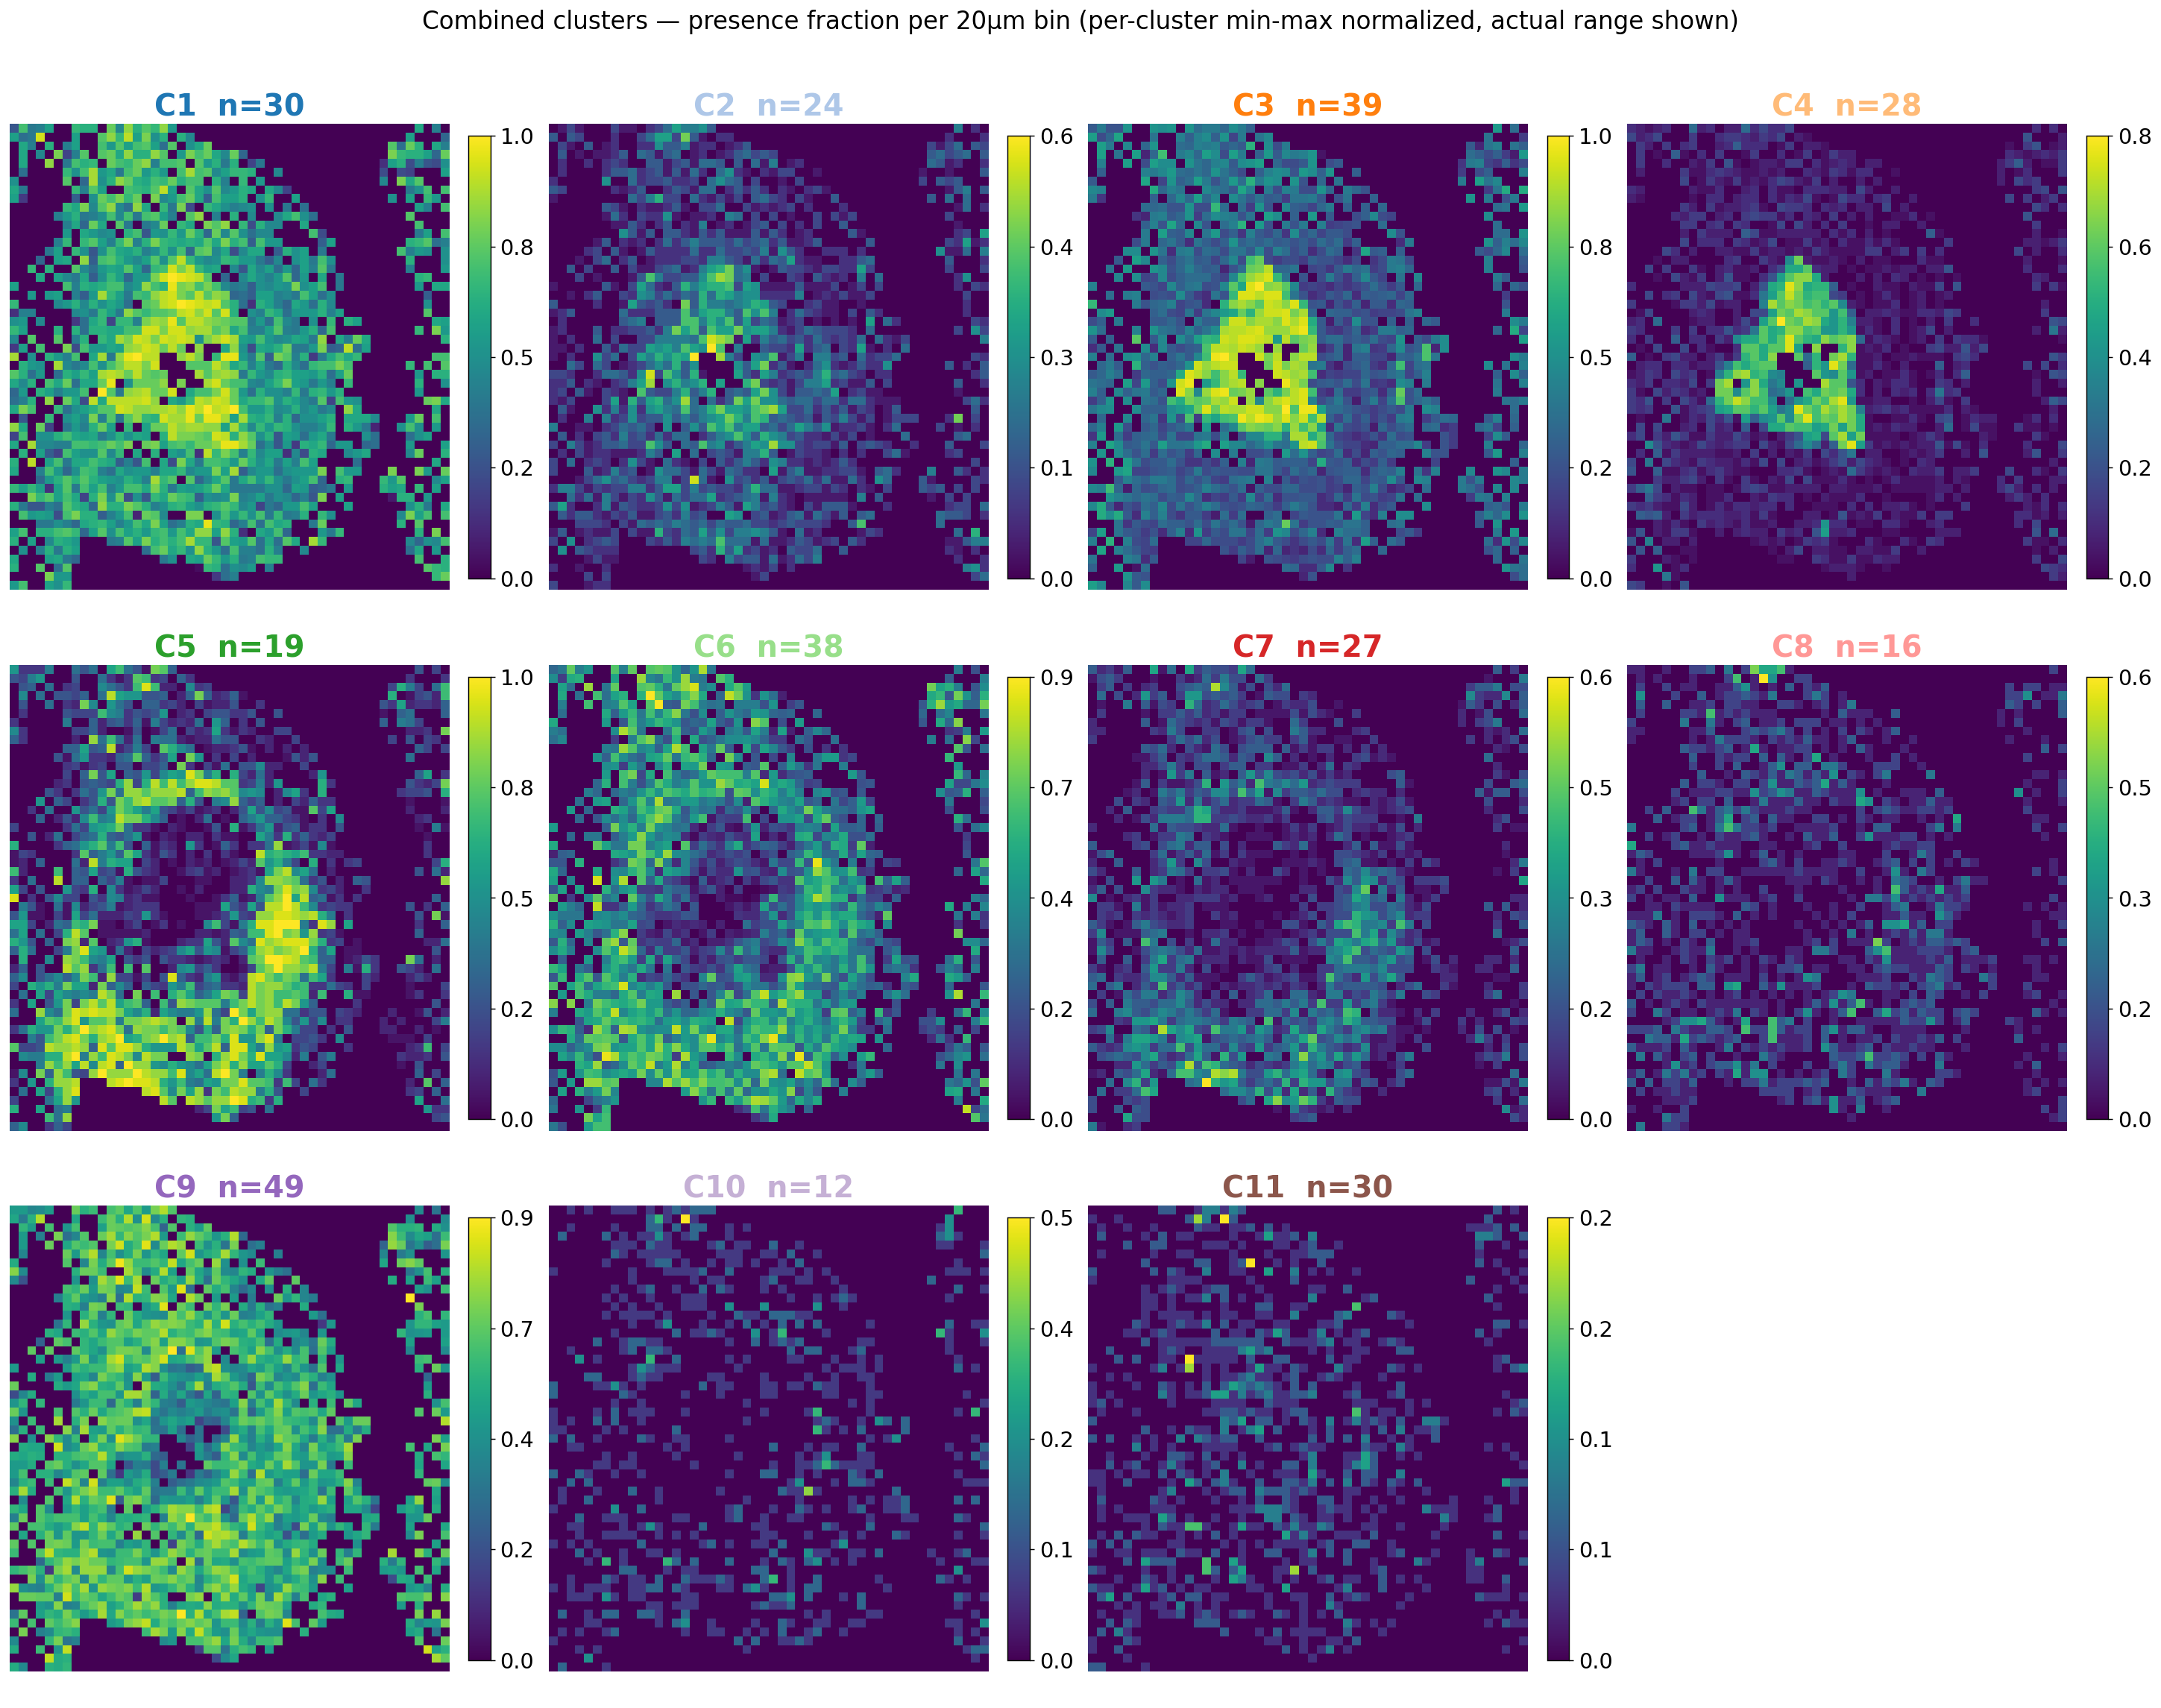

In [19]:
# All clusters × 20µm-bin presence fraction (min-max normalized independently per
# cluster; colorbar ticks show that cluster's actual values)
n = len(pres_maps)
n_cols = 4
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.6 * n_cols, 5.8 * n_rows), dpi=130,
                          sharex=True, sharey=True, squeeze=False)

tick_positions = np.linspace(0, 1, 5)

for i, (label, m) in enumerate(pres_maps.items()):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]
    lo, hi = m.min(), m.max()
    m_norm = (m - lo) / (hi - lo) if hi > lo else np.zeros_like(m)

    im = ax.imshow(m_norm, cmap="viridis", aspect="equal", origin="upper",
                    vmin=0, vmax=1, interpolation="nearest")
    title = label.split("\n")[0]
    ax.set_title(title, fontsize=22, fontweight="bold", color=pres_colors[label])
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=tick_positions)
    cbar.ax.set_yticklabels([f"{lo + t * (hi - lo):.1f}" for t in tick_positions])
    cbar.ax.tick_params(labelsize=16)

for i in range(n, n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row][col].axis("off")

fig.suptitle("Combined clusters — presence fraction per 20µm bin (per-cluster min-max normalized, actual range shown)",
             fontsize=18, y=1.01)
fig.tight_layout()
plt.show()

## 6. GO enrichment (background restricted to this panel's genes, optional)

In [20]:
from scomv.gene_module import run_go_enrichment_per_cluster, plot_go_enrichment_per_cluster

cluster_genes_for_go = {f"C{num}": info["genes"] for num, info in unified.items()}
background_genes_go = list(coords.index)

go_results = run_go_enrichment_per_cluster(
    cluster_genes_for_go,
    background_genes=background_genes_go,
    gene_sets=["GO_Biological_Process_2023", "GO_Molecular_Function_2023"],
)
n_with_hits = sum(not df.empty for df in go_results.values())
print(f"{n_with_hits} / {len(go_results)} clusters have at least one significant GO term")

3 / 11 clusters have at least one significant GO term


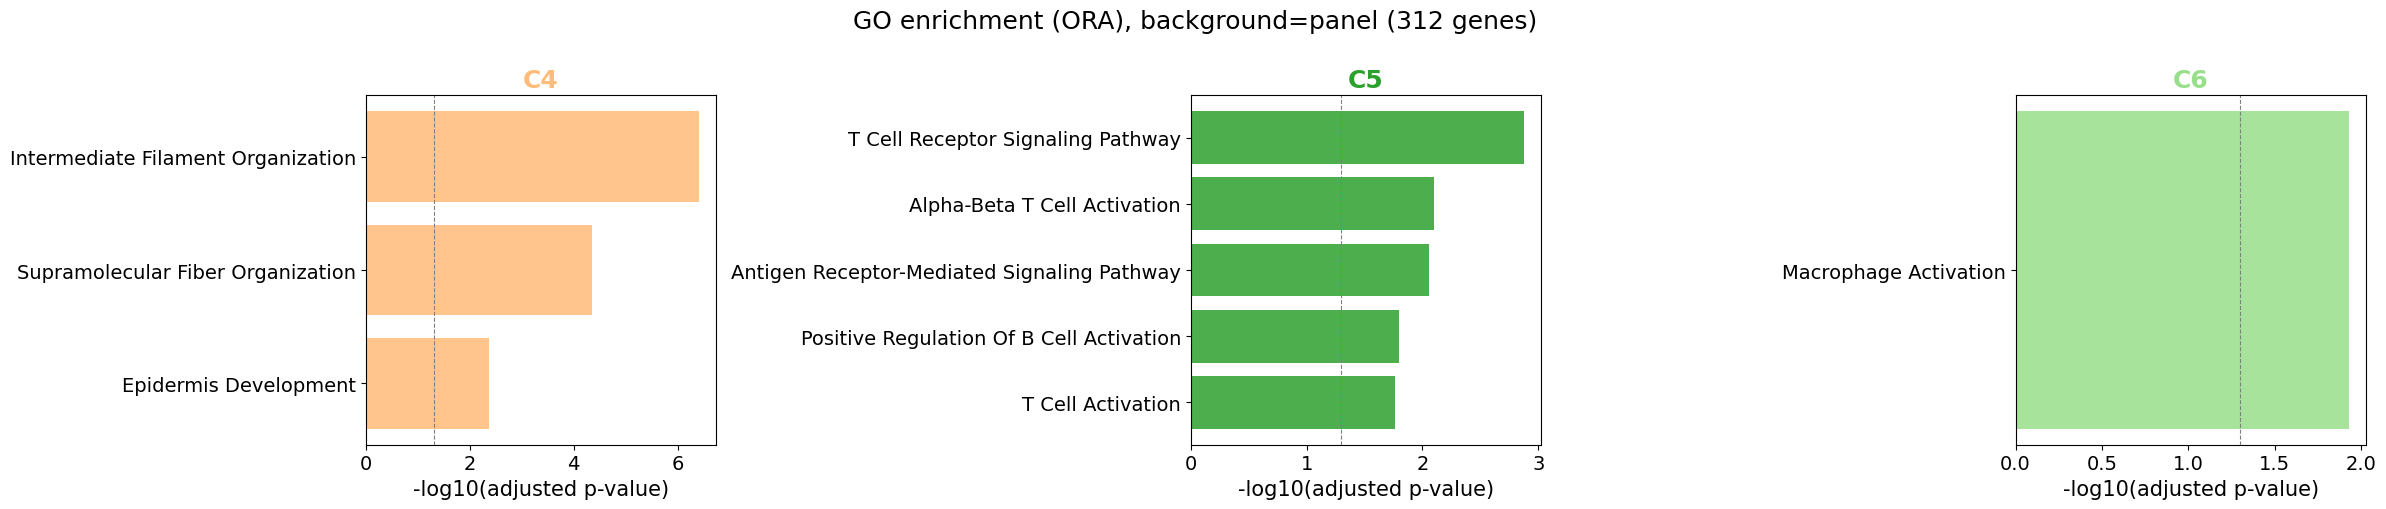

In [21]:
go_colors = {f"C{num}": cmap_combined[i % len(cmap_combined)] for i, (num, info) in enumerate(unified.items())}

fig = plot_go_enrichment_per_cluster(
    go_results, top_n=5, n_cols=3,
    colors=go_colors,
    suptitle=f"GO enrichment (ORA), background=panel ({len(background_genes_go)} genes)",
)
if fig is not None:
    plt.show()
else:
    print("No significant GO terms found.")

In [22]:
go_results_nobg = run_go_enrichment_per_cluster(
    cluster_genes_for_go,
    background_genes=None,
    gene_sets=["GO_Biological_Process_2023", "GO_Molecular_Function_2023"],
)
n_with_hits_nobg = sum(not df.empty for df in go_results_nobg.values())
print(f"{n_with_hits_nobg} / {len(go_results_nobg)} clusters have at least one significant GO term")

10 / 11 clusters have at least one significant GO term


/Users/nomura/SpatialCompassV_3/src/scomv/gene_module.py:1013: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



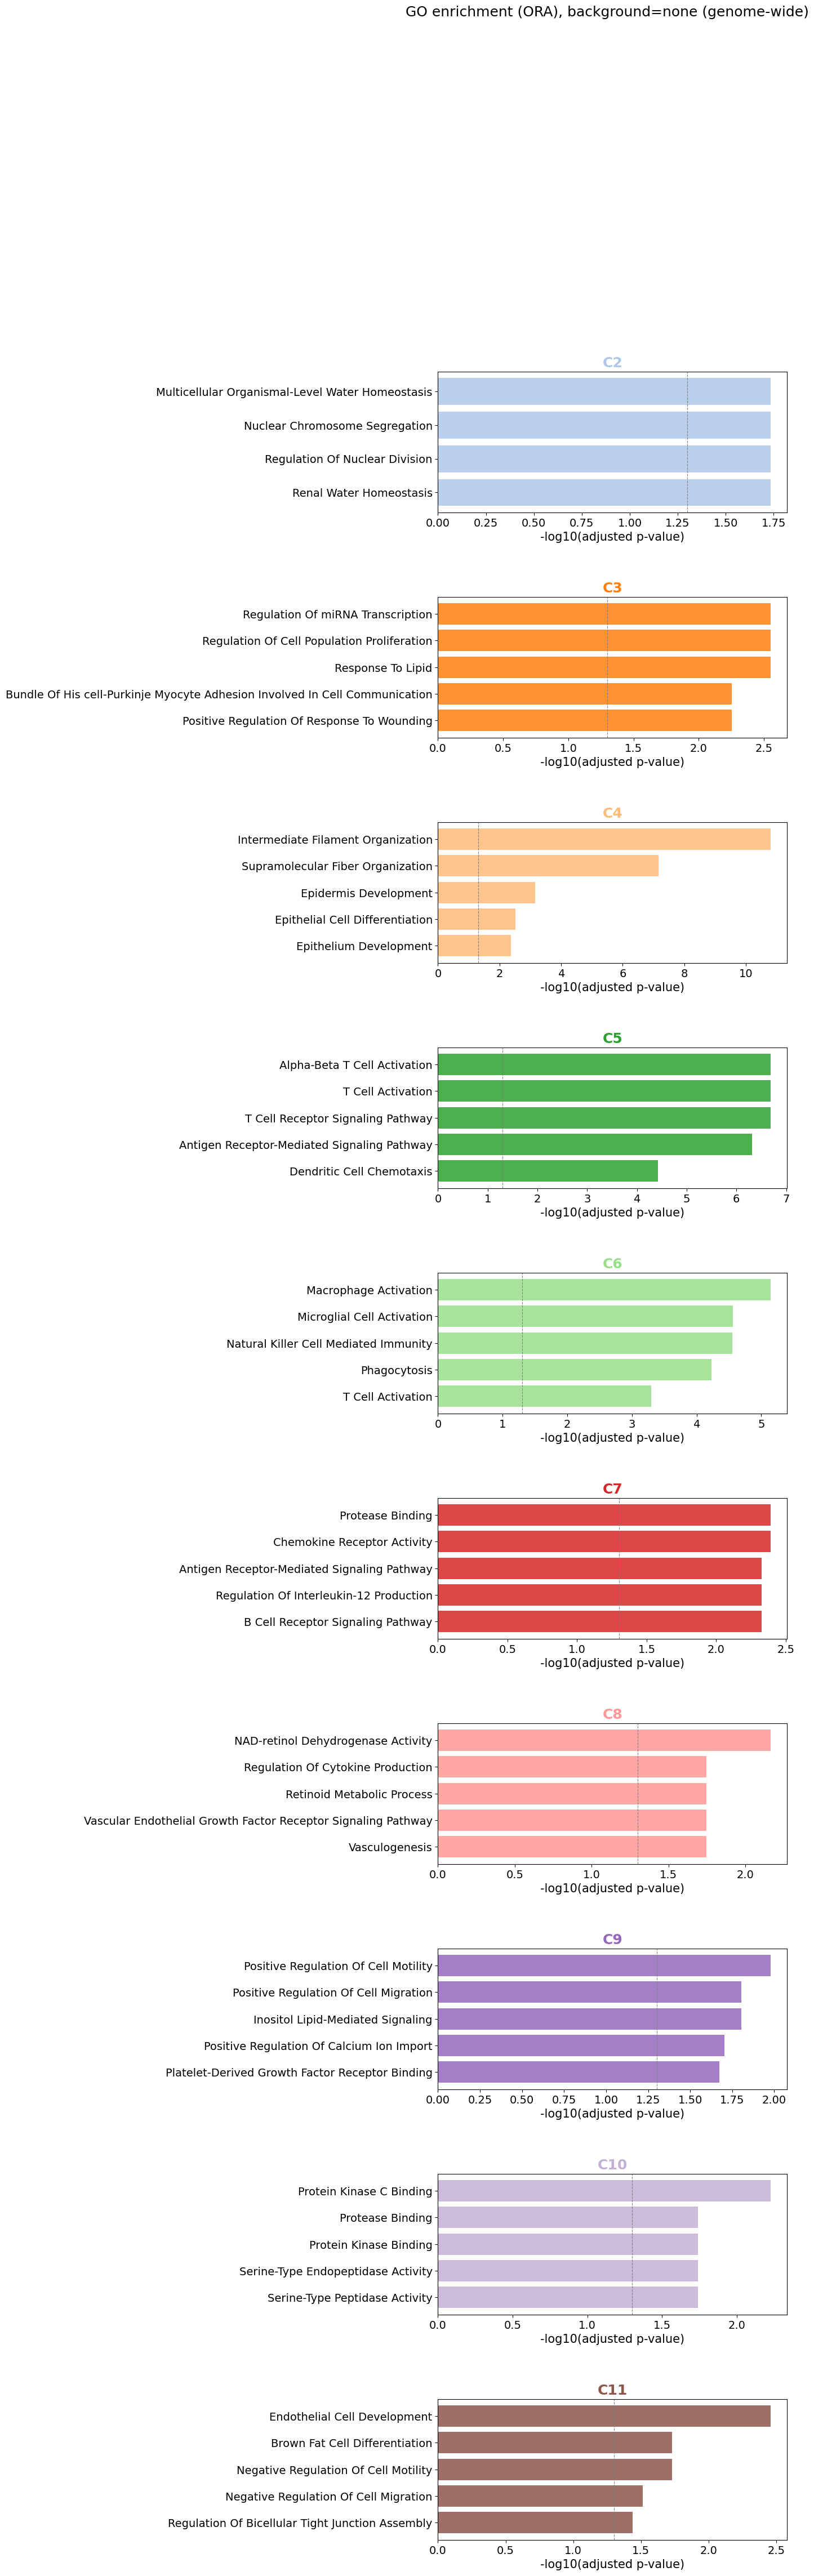

In [23]:
fig = plot_go_enrichment_per_cluster(
    go_results_nobg, top_n=5, n_cols=1,
    colors=go_colors,
    suptitle="GO enrichment (ORA), background=none (genome-wide)",
)
if fig is not None:
    plt.show()
else:
    print("No significant GO terms found.")

In [24]:
from scomv.plot_3d import plot_3d
import plotly.io as pio

fig = plot_3d(
    adata=gene_out["subset_grid"],
    genes=("POSTN", "CD3E"),
    anchor_gene="CDH1",
    bin_size=10,
    x_range=(2400, 3100),
    y_range=(2400, 3400),
    height_scale=3,
    anchor_scale=1,
    threshold=4,
    sigma=1.0,
)
pio.renderers.default = "notebook_connected"
fig.show()


CD3E: n=3431


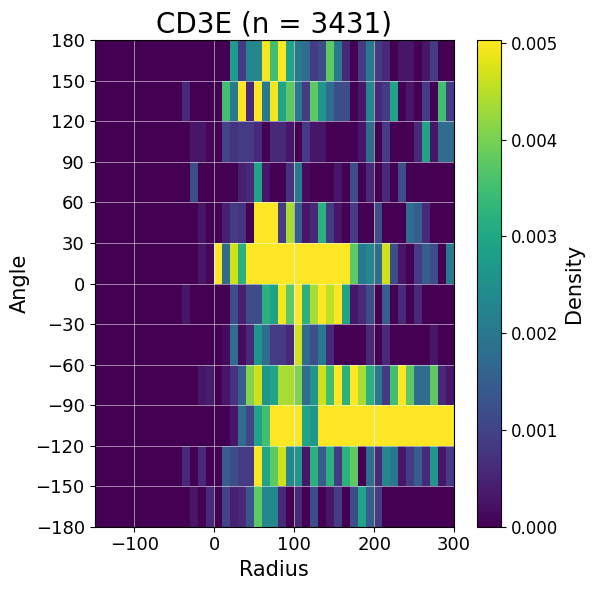

In [25]:
from scomv.polar_slice_viewer import plot_polar_slice_interactive
from scomv.gene_view_tool import plot_gene_polar_hist2d, plot_2d_expression

A_counts, _, _ = plot_gene_polar_hist2d(
    subset_grid=gene_pipe.subset_grid,
    min_vector_df=gene_pipe.min_vector_df,
    gene="CD3E",
)

POSTN: n=45705


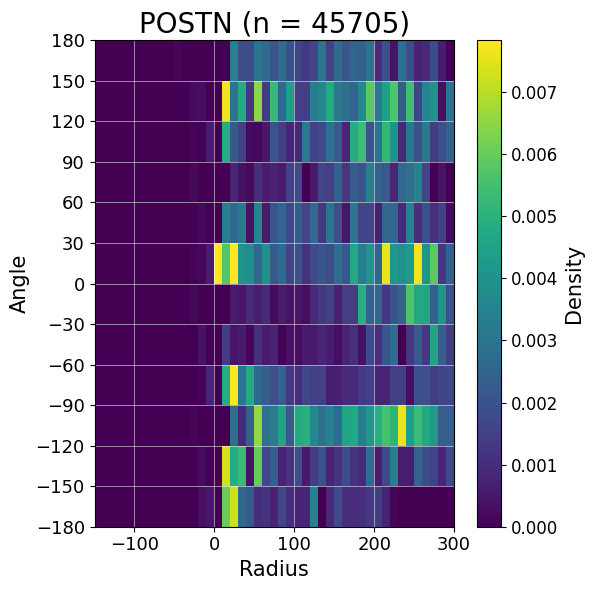

In [26]:
A_counts, _, _ = plot_gene_polar_hist2d(
    subset_grid=gene_pipe.subset_grid,
    min_vector_df=gene_pipe.min_vector_df,
    gene="POSTN",
)